# 💊 PharmaCast: Intelligent Drug Demand Forecasting
### Pharmaceutical Supply Chain Optimization — Local & Global Forecasting Models
---
**Dataset:** Pharmaceutical Weekly Sales (2014–2019) | **Rows:** 302 | **Drugs:** 8  
**Goal:** Forecast 8-week drug demand | **Validate:** Against real held-out actuals  
**Models:** Naive → SARIMA → Prophet → XGBoost → LightGBM Local → LightGBM Global
---

## 📦 Phase 1 — Environment Setup

In [ ]:
%pip install prophet lightgbm xgboost statsmodels scikit-learn -q

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

DRUG_NAMES = {
    'M01AB': 'Anti-inflammatory (COX)',
    'M01AE': 'Anti-inflammatory (Propionic)',
    'N02BA': 'Analgesics (Salicylic)',
    'N02BE': 'Analgesics / Paracetamol',
    'N05B':  'Anxiolytics',
    'N05C':  'Hypnotics & Sedatives',
    'R03':   'Respiratory / Asthma',
    'R06':   'Antihistamines'
}
DRUG_CODES = list(DRUG_NAMES.keys())
print('✅ All libraries loaded successfully')
print(f'📊 Tracking {len(DRUG_CODES)} drug categories: {DRUG_CODES}')

✅ All libraries loaded successfully
📊 Tracking 8 drug categories: ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']


## 📂 Phase 2 — Data Loading

In [ ]:
df_raw = pd.read_csv('salesweekly.csv')
print('── RAW DATA PREVIEW ──')
print(df_raw.head())
print(f'\nShape: {df_raw.shape}')

── RAW DATA PREVIEW ──
       datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03   R06
0   1/5/2014  14.00  11.67  21.30 185.95 41.00  0.00 32.00  7.00
1  1/12/2014  29.33  12.68  37.90 190.70 88.00  5.00 21.00  7.20
2  1/19/2014  30.67  26.34  45.90 218.40 80.00  8.00 29.00 12.00
3  1/26/2014  34.00  32.37  31.50 179.60 80.00  8.00 23.00 10.00
4   2/2/2014  31.02  23.35  20.70 159.88 84.00 12.00 29.00 12.00

Shape: (302, 9)


In [ ]:
df = df_raw.copy()
df['datum'] = pd.to_datetime(df['datum'])
df = df.set_index('datum').sort_index()
df.columns = [DRUG_NAMES[col] for col in df.columns]
print(f'Date range: {df.index.min().date()} → {df.index.max().date()} | {len(df)} weeks')

Date range: 2014-01-05 → 2019-10-13 | 302 weeks


In [ ]:
date_diffs = df.index.to_series().diff().dropna()
gaps = date_diffs[date_diffs != pd.Timedelta('7 days')]
print('✅ No frequency gaps' if len(gaps)==0 else f'⚠️ {len(gaps)} gaps')
print(f'Interval: {date_diffs.mode()[0]}')

✅ No frequency gaps
Interval: 7 days 00:00:00


## 🔍 Phase 3 — Data Quality

In [ ]:
print('── MISSING VALUES ──')
print(df.isnull().sum())
print(f'\nDuplicate dates: {df.index.duplicated().sum()}')
print('\n── ZERO VALUES ──')
print((df == 0).sum())

── MISSING VALUES ──
Anti-inflammatory (COX)          0
Anti-inflammatory (Propionic)    0
Analgesics (Salicylic)           0
Analgesics / Paracetamol         0
Anxiolytics                      0
Hypnotics & Sedatives            0
Respiratory / Asthma             0
Antihistamines                   0
dtype: int64

Duplicate dates: 0

── ZERO VALUES ──
Anti-inflammatory (COX)           0
Anti-inflammatory (Propionic)     0
Analgesics (Salicylic)            0
Analgesics / Paracetamol          0
Anxiolytics                       0
Hypnotics & Sedatives            36
Respiratory / Asthma              0
Antihistamines                    0
dtype: int64


In [ ]:
stats = df.describe().T
stats['CV (%)'] = (stats['std'] / stats['mean'] * 100).round(1)
stats = stats[['mean','std','CV (%)','min','max']]
stats.columns = ['Mean/Week','Std Dev','Volatility (%)','Min','Max']
print(stats.sort_values('Volatility (%)', ascending=False).round(2))

                               Mean/Week  Std Dev  Volatility (%)   Min    Max
Hypnotics & Sedatives               4.14     3.13           75.60  0.00  17.00
Respiratory / Asthma               38.44    22.90           59.60  2.00 131.00
Antihistamines                     20.22    11.38           56.30  1.00  65.00
Analgesics / Paracetamol          208.63    76.07           36.50 86.25 546.90
Anxiolytics                        61.74    22.44           36.30 18.00 154.00
Analgesics (Salicylic)             27.06     8.09           29.90  3.50  60.12
Anti-inflammatory (Propionic)      27.17     7.04           25.90  6.24  53.57
Anti-inflammatory (COX)            35.10     8.62           24.50  7.67  65.33


## 📊 Phase 4 — EDA

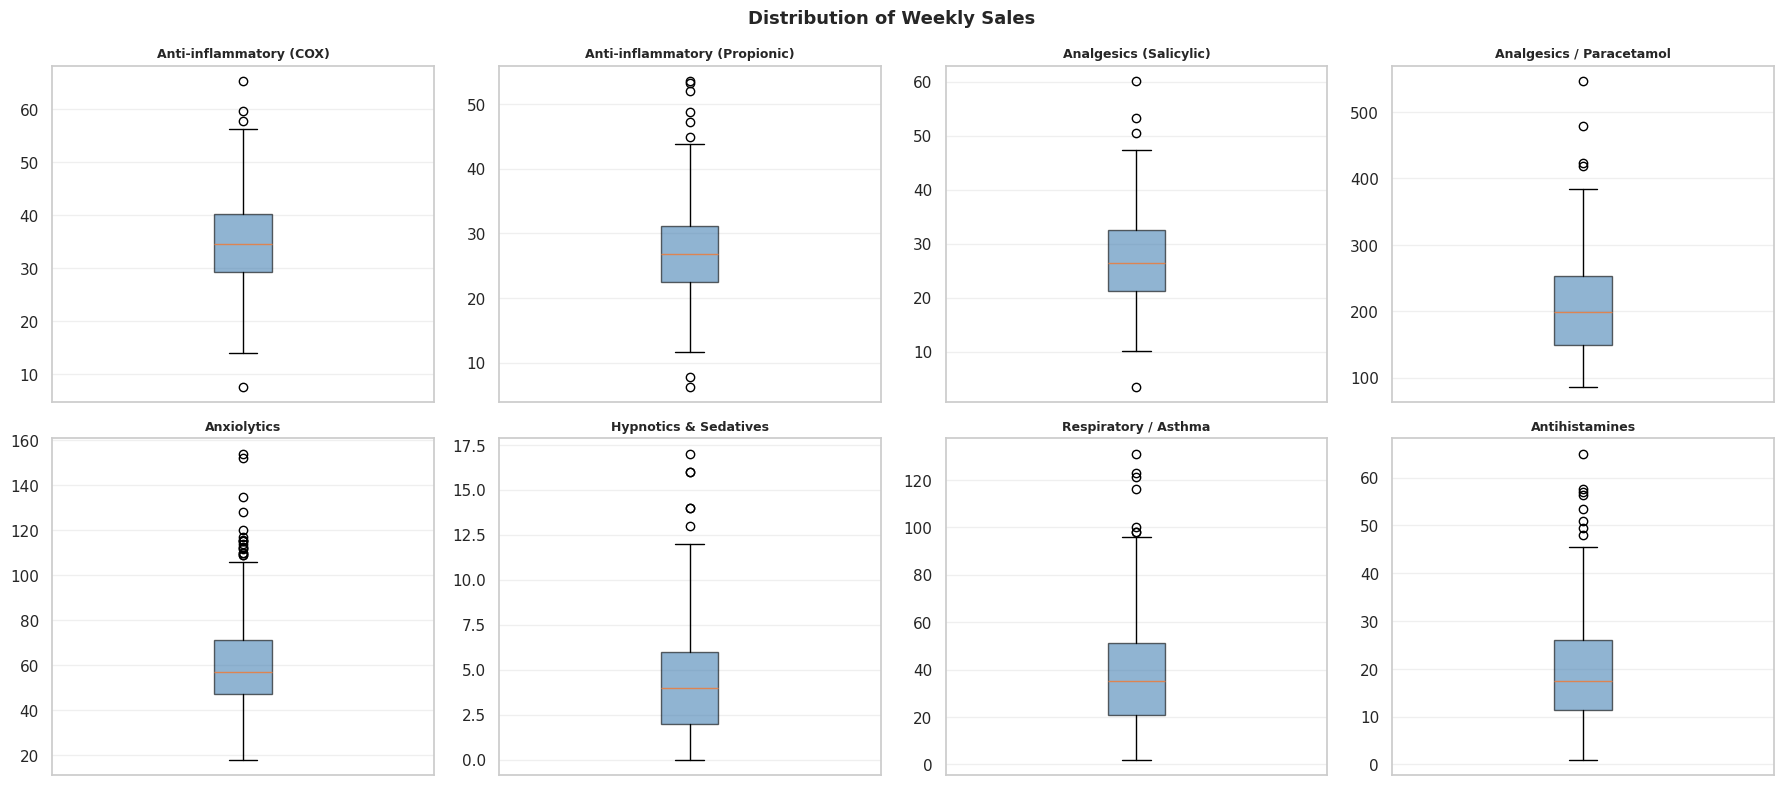

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, drug in enumerate(df.columns):
    axes[i].boxplot(df[drug].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(drug, fontsize=9, fontweight='bold')
    axes[i].set_xticks([])
plt.suptitle('Distribution of Weekly Sales', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

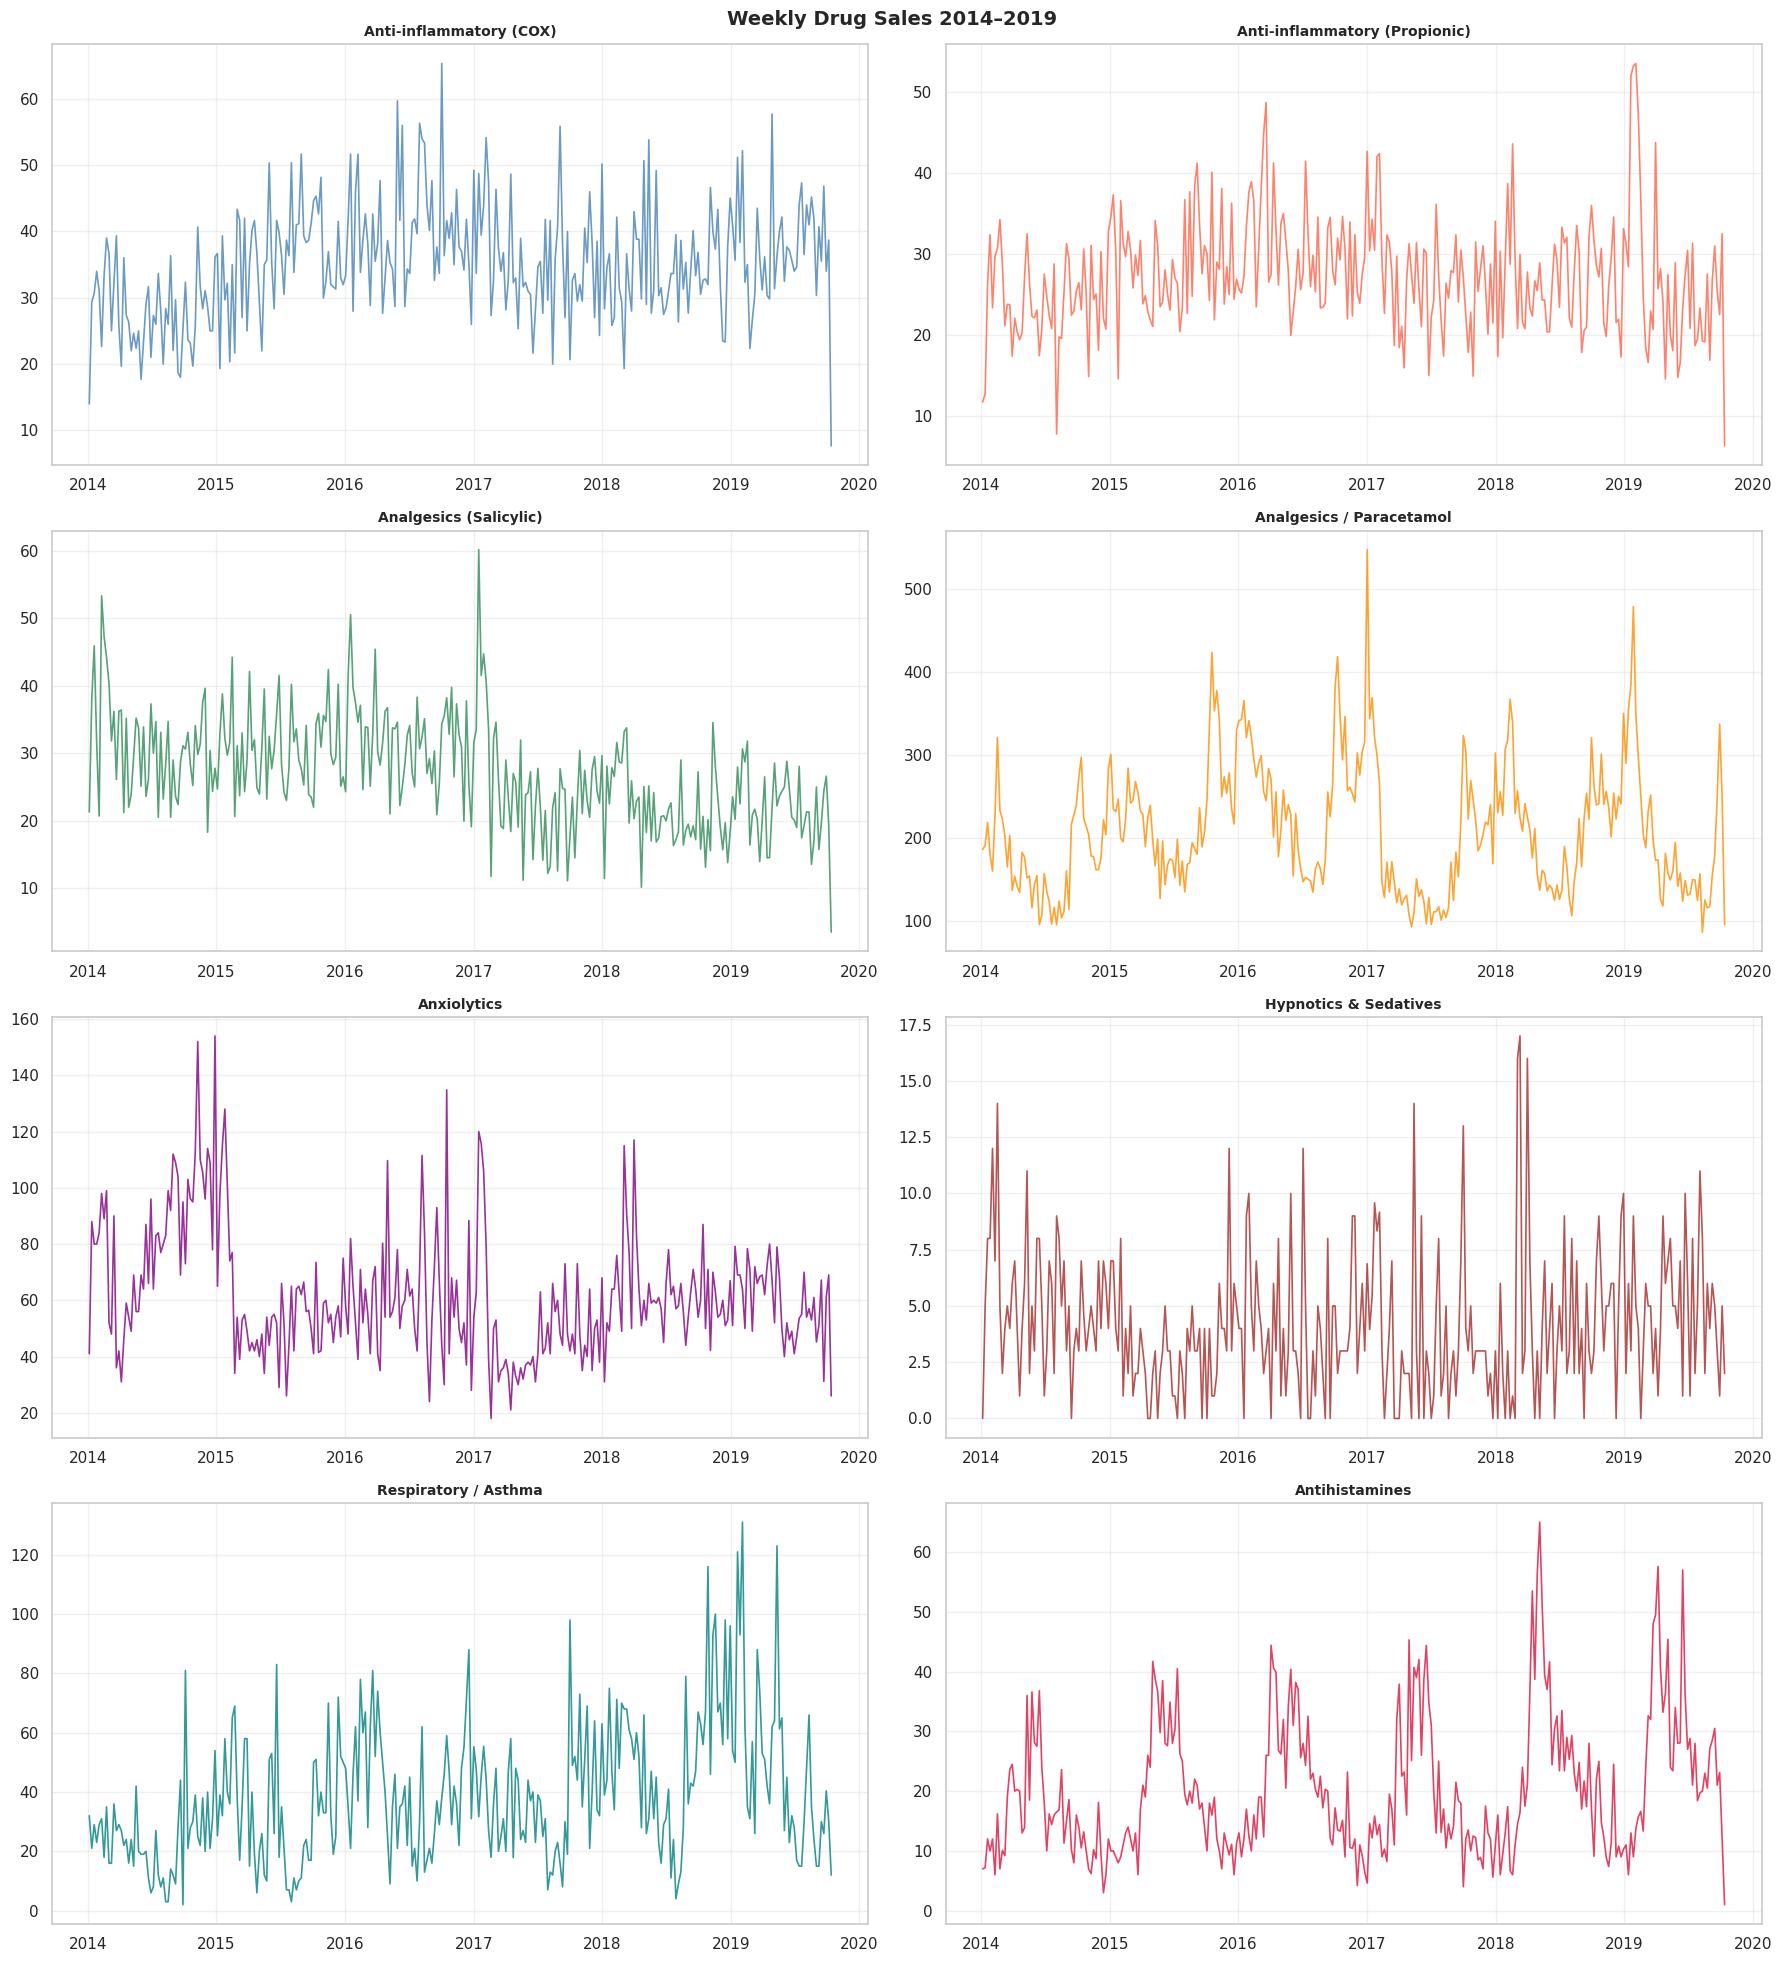

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()
colors = ['steelblue','tomato','seagreen','darkorange','purple','brown','teal','crimson']
for i, drug in enumerate(df.columns):
    axes[i].plot(df.index, df[drug], color=colors[i], linewidth=1.2, alpha=0.8)
    axes[i].set_title(drug, fontsize=10, fontweight='bold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Weekly Drug Sales 2014–2019', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

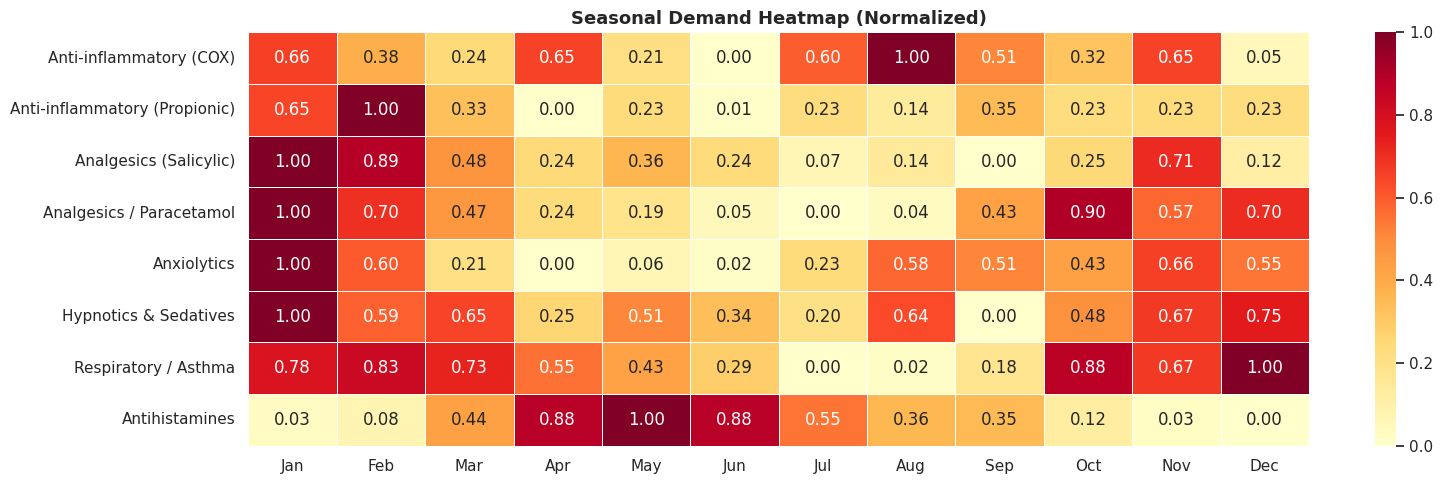

In [ ]:
df_monthly = df.copy()
df_monthly['Month'] = df.index.month
monthly_avg  = df_monthly.groupby('Month')[df.columns.tolist()].mean()
monthly_norm = (monthly_avg - monthly_avg.min()) / (monthly_avg.max() - monthly_avg.min())
monthly_norm.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(16, 5))
sns.heatmap(monthly_norm.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Seasonal Demand Heatmap (Normalized)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

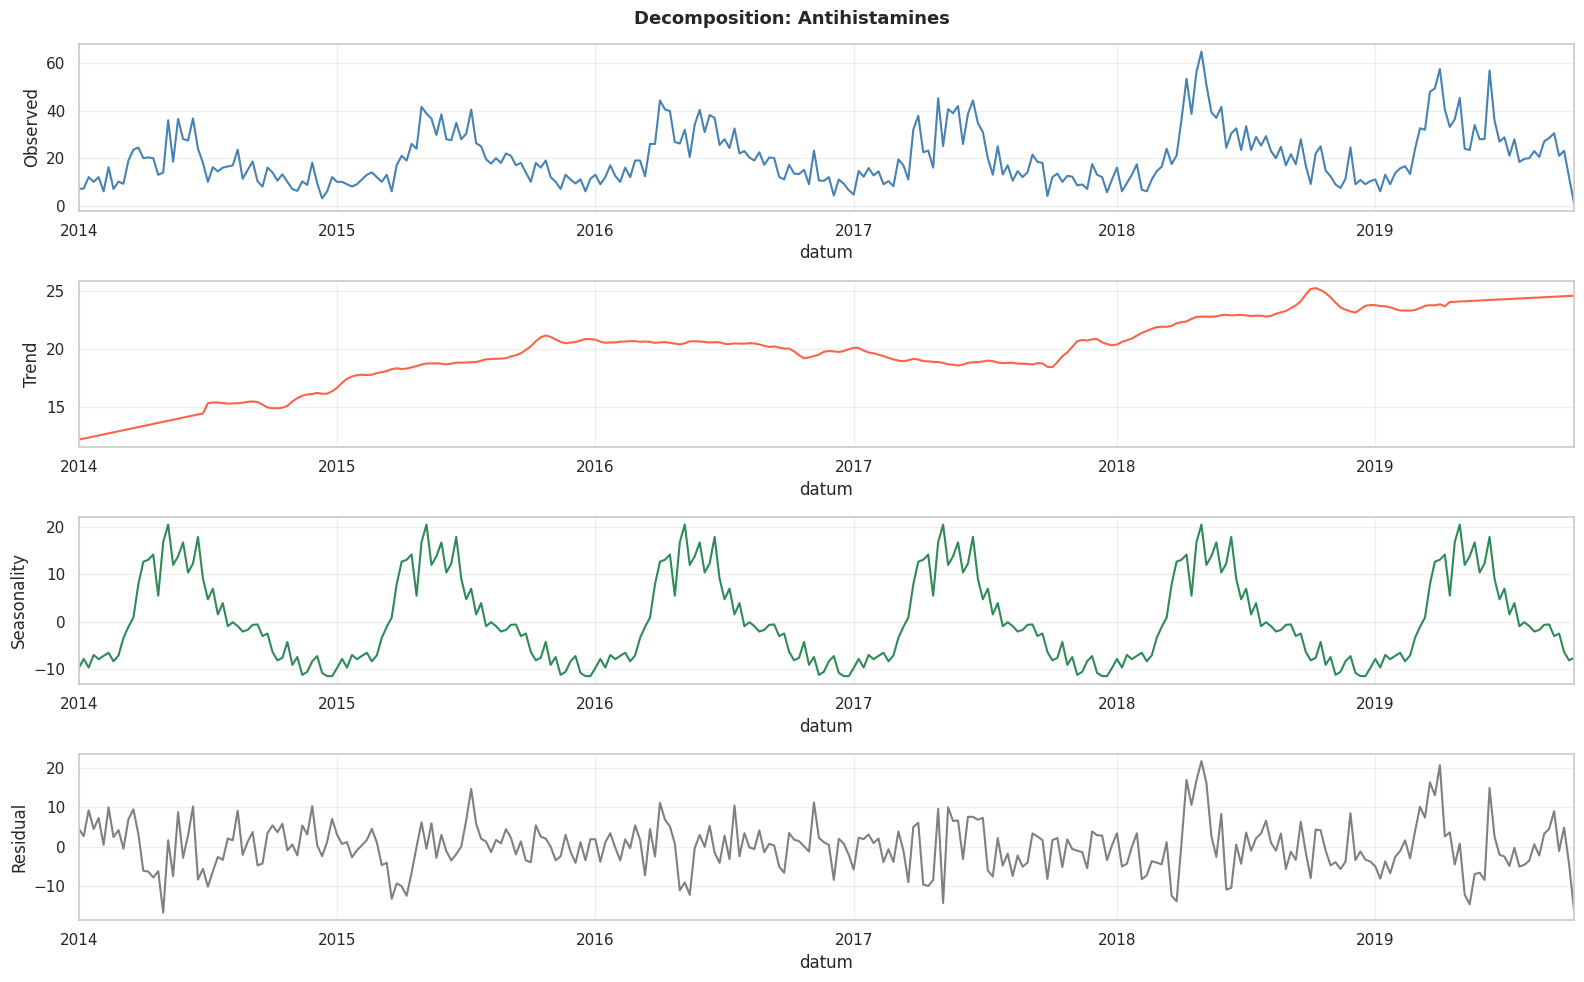

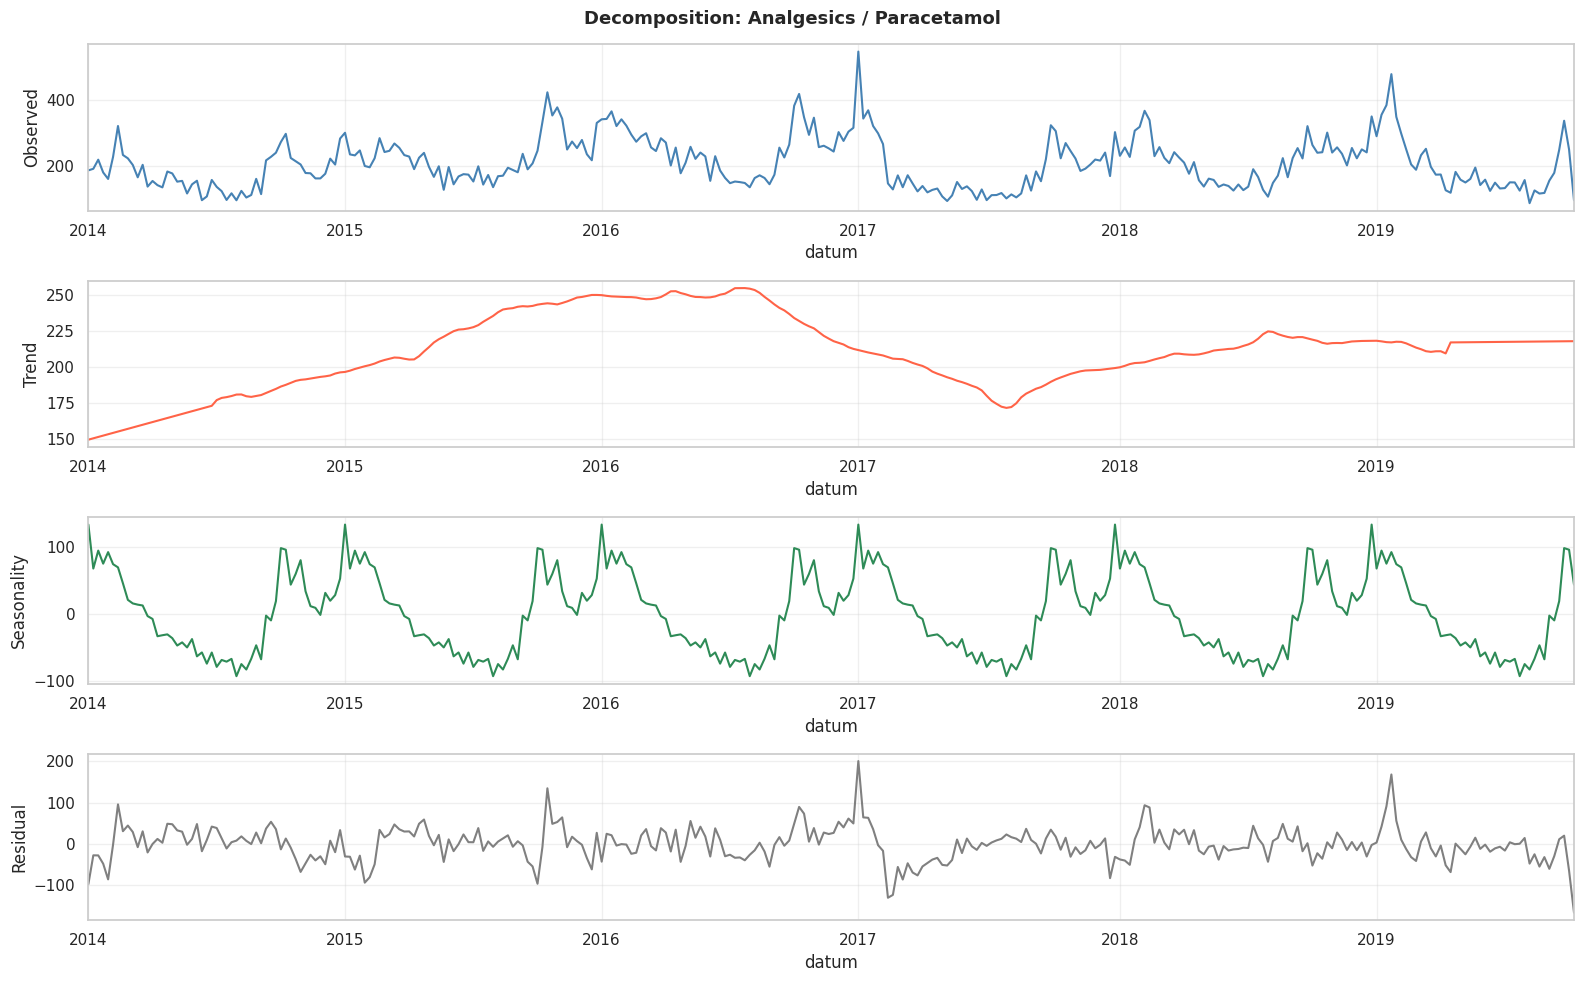

In [ ]:
for drug in ['Antihistamines','Analgesics / Paracetamol']:
    result = seasonal_decompose(df[drug], model='additive', period=52, extrapolate_trend='freq')
    fig, axes = plt.subplots(4, 1, figsize=(16, 10))
    result.observed.plot(ax=axes[0],  color='steelblue'); axes[0].set_ylabel('Observed')
    result.trend.plot(ax=axes[1],     color='tomato');    axes[1].set_ylabel('Trend')
    result.seasonal.plot(ax=axes[2],  color='seagreen');  axes[2].set_ylabel('Seasonality')
    result.resid.plot(ax=axes[3],     color='gray');      axes[3].set_ylabel('Residual')
    plt.suptitle(f'Decomposition: {drug}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## 📉 Phase 5 — Stationarity (ADF Test)

In [ ]:
print('── ADF TEST RESULTS ──\n')
print(f'{"Drug":<35} {"p-value":>10} {"Stationary?":>20}')
print('-' * 68)
adf_results = {}
for drug in df.columns:
    adf_stat, p_val, *_ = adfuller(df[drug].dropna())
    is_stat = p_val < 0.05
    adf_results[drug] = {'stationary': is_stat}
    print(f'{drug:<35} {p_val:>10.4f} {"YES ✅" if is_stat else "NO ❌":>20}')

── ADF TEST RESULTS ──

Drug                                   p-value          Stationary?
--------------------------------------------------------------------
Anti-inflammatory (COX)                 0.0052                YES ✅
Anti-inflammatory (Propionic)           0.0000                YES ✅
Analgesics (Salicylic)                  0.4201                 NO ❌
Analgesics / Paracetamol                0.0003                YES ✅
Anxiolytics                             0.0058                YES ✅
Hypnotics & Sedatives                   0.0000                YES ✅
Respiratory / Asthma                    0.0104                YES ✅
Antihistamines                          0.0000                YES ✅


## ⚙️ Phase 6 — Feature Engineering

In [ ]:
def create_features(series, drug_name):
    data = pd.DataFrame({'sales': series})
    data['lag_1']  = data['sales'].shift(1)
    data['lag_4']  = data['sales'].shift(4)
    data['lag_8']  = data['sales'].shift(8)
    data['lag_12'] = data['sales'].shift(12)
    data['lag_52'] = data['sales'].shift(52)
    data['roll_mean_4']  = data['sales'].shift(1).rolling(4,  min_periods=1).mean()
    data['roll_mean_12'] = data['sales'].shift(1).rolling(12, min_periods=1).mean()
    data['roll_std_4']   = data['sales'].shift(1).rolling(4,  min_periods=1).std().fillna(0)
    data['month']   = data.index.month
    data['quarter'] = data.index.quarter
    data['week']    = data.index.isocalendar().week.astype(int)
    data['year']    = data.index.year
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
    data['lag_52']  = data['lag_52'].fillna(data['roll_mean_12'])
    seasonal_flags = {
        'Antihistamines':           lambda m: 1 if m in [3,4,5]       else 0,
        'Respiratory / Asthma':     lambda m: 1 if m in [10,11,12,1]  else 0,
        'Analgesics / Paracetamol': lambda m: 1 if m in [10,11,12,1]  else 0,
        'Analgesics (Salicylic)':   lambda m: 1 if m in [10,11,12,1]  else 0,
    }
    data['is_peak_season'] = (
        data['month'].apply(seasonal_flags[drug_name])
        if drug_name in seasonal_flags else 0
    )
    data['yoy_growth'] = (data['sales'] - data['lag_52']) / (data['lag_52'].abs() + 1)
    data['peak_lag52_interaction'] = data['lag_52'] * data['is_peak_season']
    data = data.fillna(method='bfill').fillna(method='ffill')
    return data

sample = create_features(df['Antihistamines'], 'Antihistamines')
print(f'Feature matrix shape: {sample.shape}')
print(f'Features: {list(sample.columns)}')

Feature matrix shape: (302, 18)
Features: ['sales', 'lag_1', 'lag_4', 'lag_8', 'lag_12', 'lag_52', 'roll_mean_4', 'roll_mean_12', 'roll_std_4', 'month', 'quarter', 'week', 'year', 'month_sin', 'month_cos', 'is_peak_season', 'yoy_growth', 'peak_lag52_interaction']


In [ ]:
# Build Global dataframe — datum preserved through merge
global_frames = []
for drug_code, drug_name in zip(DRUG_CODES, df.columns):
    drug_df = create_features(df[drug_name], drug_name).copy()
    drug_df['drug_name'] = drug_name
    drug_df['drug_code'] = drug_code
    global_frames.append(drug_df)

df_global_v2 = pd.concat(global_frames)
le = LabelEncoder()
df_global_v2['drug_id'] = le.fit_transform(df_global_v2['drug_name'])
drug_stats2 = (df_global_v2.groupby('drug_name')['sales']
               .agg(['mean','std'])
               .rename(columns={'mean':'drug_mean','std':'drug_std'}))
df_global_v2 = df_global_v2.reset_index()
df_global_v2 = df_global_v2.rename(columns={'index':'datum'}) if 'index' in df_global_v2.columns else df_global_v2
df_global_v2 = df_global_v2.merge(drug_stats2, on='drug_name', how='left')
df_global_v2['drug_cv'] = df_global_v2['drug_std'] / df_global_v2['drug_mean']
df_global_v2['datum'] = pd.to_datetime(df_global_v2['datum'])
df_global_v2 = df_global_v2.set_index('datum').sort_index()
df_global = df_global_v2.copy()
print(f'Global shape: {df_global_v2.shape} | Index: {df_global_v2.index.dtype}')
assert isinstance(df_global_v2.index, pd.DatetimeIndex)
print('✅ Global dataframe ready')

Global shape: (2416, 24) | Index: datetime64[ns]
✅ Global dataframe ready


## ✂️ Phase 7 — Train / Validation / Test / Forecast Split

**Design decision — clean forecast validation:**
```
Jan 2014 → Sep 2018  =  TRAIN       (244 weeks — model learning)
Sep 2018 → Feb 2019  =  VALIDATION  (21 weeks  — hyperparameter tuning)
Feb 2019 → Jul 2019  =  TEST        (21 weeks  — model comparison table)
Jul 2019 → Sep 2019  =  FORECAST    (8 weeks   — recursive prediction + validate vs actuals)
Oct 2019             =  DROPPED     (boundary anomaly — extreme values)
```
**Why this design:** Oct 2019 actuals show extreme drops/spikes inconsistent with patterns — a known dataset boundary effect. Moving the forecast window to Jul–Sep 2019 gives a clean, stable validation period where real actuals exist and patterns are predictable.

Train:           2014-01-05 → 2018-09-02 | 244 weeks
Validation:      2018-09-09 → 2019-01-27 | 21 weeks
Test:            2019-02-03 → 2019-07-14 | 24 weeks
Forecast window: 2019-07-21 → 2019-09-15 | 9 weeks


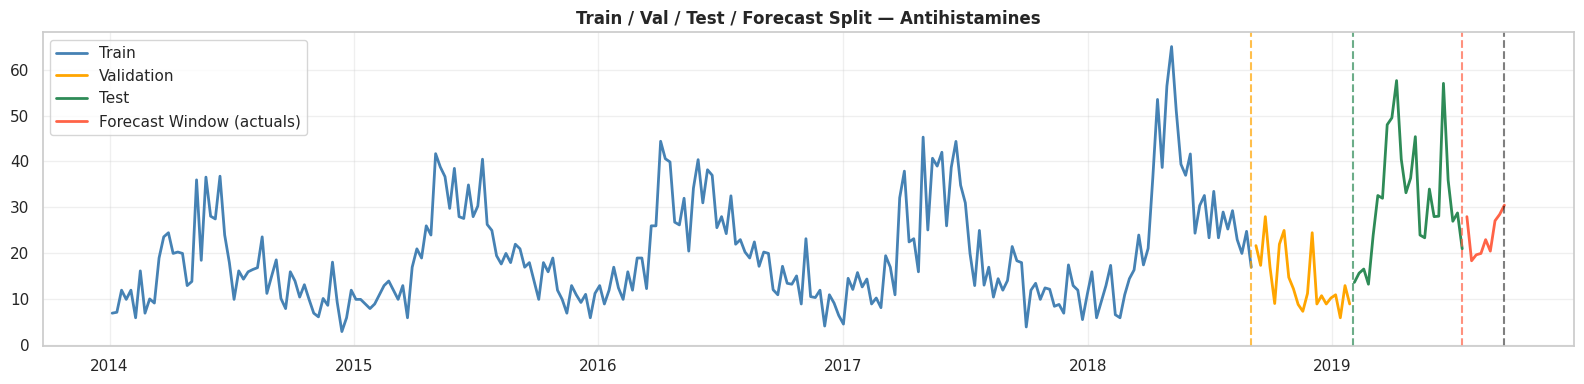


💡 Forecast window: Jul–Sep 2019 — stable mid-dataset period, real actuals available


In [ ]:
# ── Split boundaries ──────────────────────────────────────────────────────────
TRAIN_END       = '2018-09-02'
VAL_END         = '2019-02-01'
TEST_END        = '2019-07-14'   # UPDATED: cleaner test window end
FORECAST_START  = '2019-07-14'   # 8-week forecast begins here
FORECAST_END    = '2019-09-15'   # 8-week forecast ends here (actuals exist ✅)

TRAIN_END_DT      = pd.to_datetime(TRAIN_END)
VAL_END_DT        = pd.to_datetime(VAL_END)
TEST_END_DT       = pd.to_datetime(TEST_END)
FORECAST_START_DT = pd.to_datetime(FORECAST_START)
FORECAST_END_DT   = pd.to_datetime(FORECAST_END)

# ── Create splits ─────────────────────────────────────────────────────────────
train           = df[df.index <= TRAIN_END_DT]
val             = df[(df.index > TRAIN_END_DT) & (df.index <= VAL_END_DT)]
test            = df[(df.index > VAL_END_DT)   & (df.index <= TEST_END_DT)]
forecast_actual = df[(df.index > FORECAST_START_DT) & (df.index <= FORECAST_END_DT)]

print(f'Train:           {train.index.min().date()} → {train.index.max().date()} | {len(train)} weeks')
print(f'Validation:      {val.index.min().date()} → {val.index.max().date()} | {len(val)} weeks')
print(f'Test:            {test.index.min().date()} → {test.index.max().date()} | {len(test)} weeks')
print(f'Forecast window: {forecast_actual.index.min().date()} → {forecast_actual.index.max().date()} | {len(forecast_actual)} weeks')

# ── Visualise split ───────────────────────────────────────────────────────────
plt.figure(figsize=(16, 4))
plt.plot(train.index,           train['Antihistamines'],           color='steelblue', lw=2,  label='Train')
plt.plot(val.index,             val['Antihistamines'],             color='orange',    lw=2,  label='Validation')
plt.plot(test.index,            test['Antihistamines'],            color='seagreen',  lw=2,  label='Test')
plt.plot(forecast_actual.index, forecast_actual['Antihistamines'], color='tomato',    lw=2,  label='Forecast Window (actuals)')
plt.axvline(TRAIN_END_DT,      color='orange',   ls='--', alpha=0.7)
plt.axvline(VAL_END_DT,        color='seagreen', ls='--', alpha=0.7)
plt.axvline(TEST_END_DT,       color='tomato',   ls='--', alpha=0.7)
plt.axvline(FORECAST_END_DT,   color='black',    ls='--', alpha=0.5)
plt.title('Train / Val / Test / Forecast Split — Antihistamines', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print('\n💡 Forecast window: Jul–Sep 2019 — stable mid-dataset period, real actuals available')

## 🔢 Phase 8 — Metric Functions

In [ ]:
def mape(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    mask = a != 0
    return np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100

def smape(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    denom = np.where((np.abs(a) + np.abs(p)) == 0, 1, np.abs(a) + np.abs(p))
    return np.mean(2 * np.abs(a - p) / denom) * 100

def evaluate(actual, predicted, model_name, drug_name):
    mae_val   = mean_absolute_error(actual, predicted)
    rmse_val  = np.sqrt(mean_squared_error(actual, predicted))
    mape_val  = mape(actual, predicted)
    smape_val = smape(actual, predicted)
    r2_val    = r2_score(actual, predicted)
    print(f'[{model_name}] {drug_name}: MAE={mae_val:.2f} | RMSE={rmse_val:.2f} | MAPE={mape_val:.1f}% | sMAPE={smape_val:.1f}% | R²={r2_val:.3f}')
    return {'model':model_name,'drug':drug_name,
            'MAE':mae_val,'RMSE':rmse_val,'MAPE':mape_val,'sMAPE':smape_val,'R2':r2_val}

all_results = []
print('✅ Metric functions ready')

✅ Metric functions ready


## 🔵 Phase 8a — Naive Baseline

In [ ]:
print('── NAIVE BASELINE (evaluated on clean test window: Feb–Jul 2019) ──\n')
for drug in df.columns:
    last_val = train[drug].iloc[-1]
    naive_fc = np.full(len(test), last_val)
    result = evaluate(test[drug].values, naive_fc, 'Naive', drug)
    all_results.append(result)

── NAIVE BASELINE (evaluated on clean test window: Feb–Jul 2019) ──

[Naive] Anti-inflammatory (COX): MAE=9.05 | RMSE=11.37 | MAPE=22.8% | sMAPE=26.5% | R²=-1.281
[Naive] Anti-inflammatory (Propionic): MAE=9.43 | RMSE=13.21 | MAPE=29.3% | sMAPE=36.7% | R²=-0.762
[Naive] Analgesics (Salicylic): MAE=4.87 | RMSE=5.99 | MAPE=20.5% | sMAPE=22.1% | R²=-0.428
[Naive] Analgesics / Paracetamol: MAE=41.49 | RMSE=59.09 | MAPE=20.5% | sMAPE=21.8% | R²=-0.097
[Naive] Anxiolytics: MAE=11.66 | RMSE=13.73 | MAPE=18.5% | sMAPE=19.7% | R²=-0.264
[Naive] Hypnotics & Sedatives: MAE=2.17 | RMSE=2.71 | MAPE=66.7% | sMAPE=53.8% | R²=-0.105
[Naive] Respiratory / Asthma: MAE=23.51 | RMSE=33.35 | MAPE=43.3% | sMAPE=46.5% | R²=-0.300
[Naive] Antihistamines: MAE=15.63 | RMSE=19.41 | MAPE=42.3% | sMAPE=56.4% | R²=-1.435


## 🔴 Phase 8b — SARIMA

── SARIMA RESULTS ──



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


[SARIMA] Antihistamines: MAE=18.45 | RMSE=21.76 | MAPE=52.6% | sMAPE=73.0% | R²=-2.060


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


[SARIMA] Analgesics / Paracetamol: MAE=36.45 | RMSE=55.81 | MAPE=17.1% | sMAPE=18.8% | R²=0.022


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


[SARIMA] Anti-inflammatory (COX): MAE=5.52 | RMSE=7.95 | MAPE=14.3% | sMAPE=15.0% | R²=-0.114


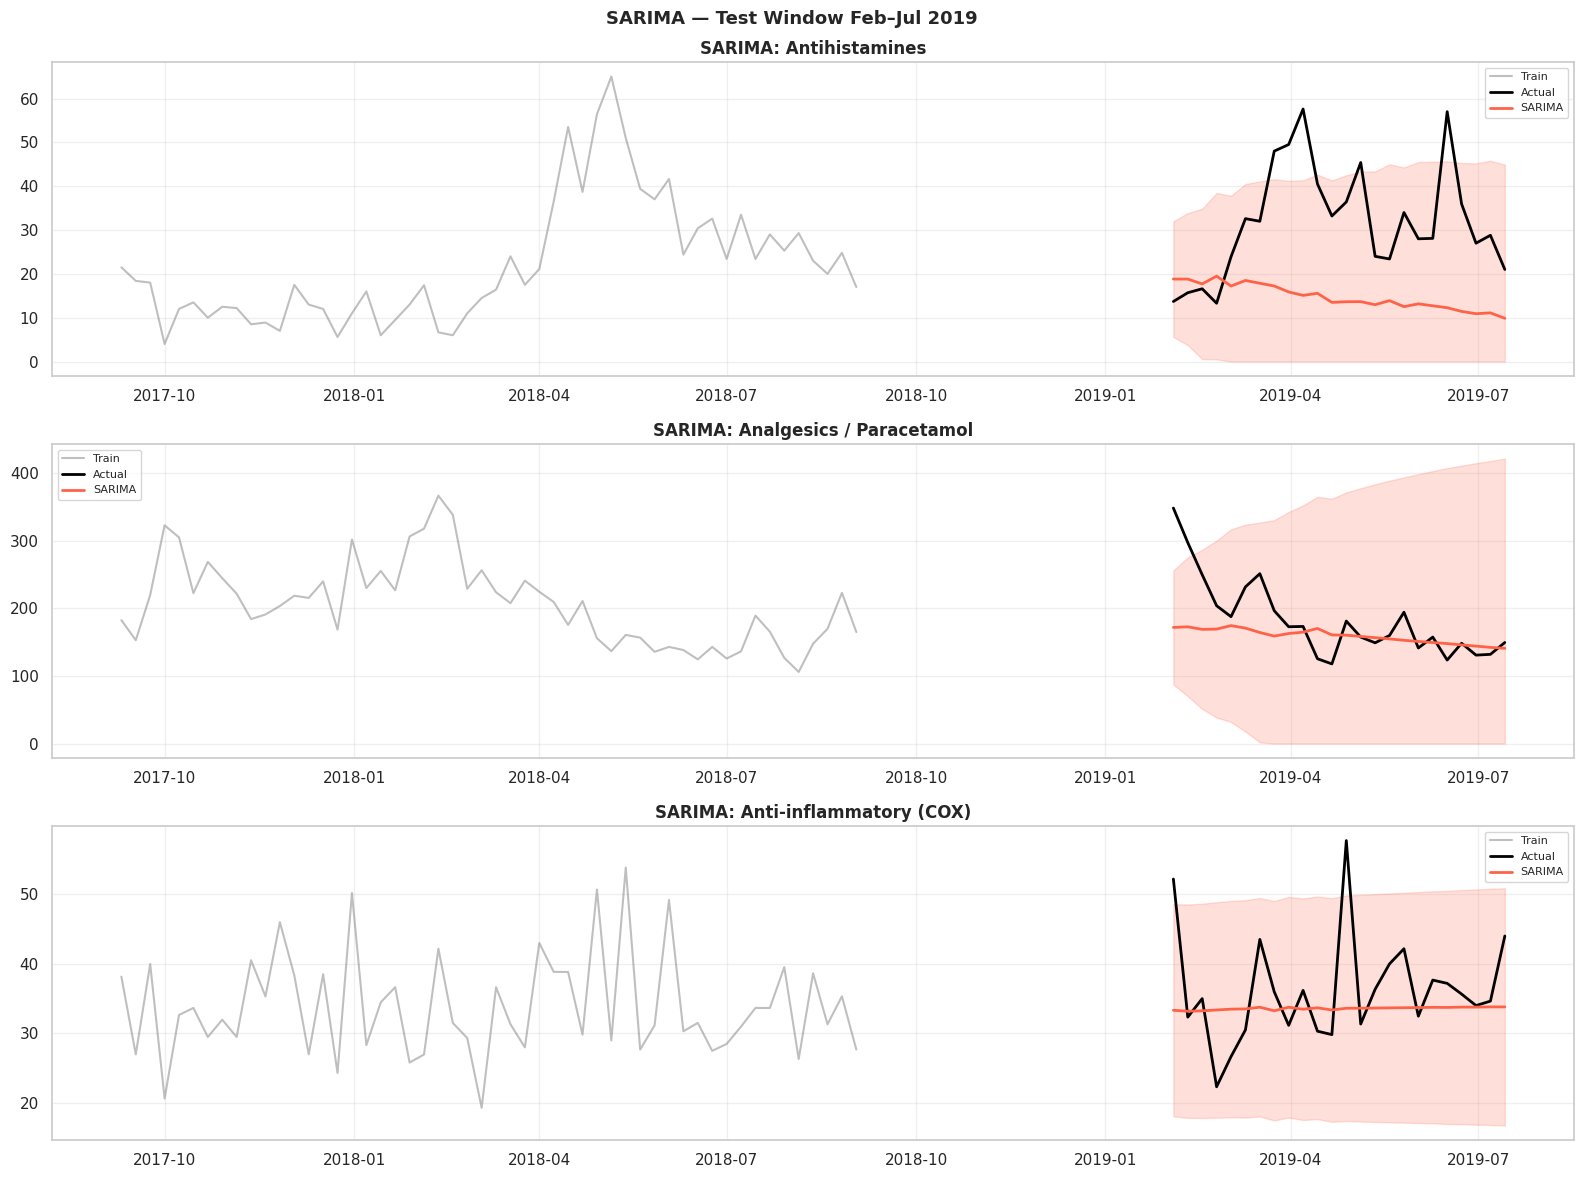

In [ ]:
sarima_drugs  = ['Antihistamines','Analgesics / Paracetamol','Anti-inflammatory (COX)']
sarima_orders = {
    'Antihistamines':           {'order':(2,0,2), 'seasonal_order':(1,0,1,12)},
    'Analgesics / Paracetamol': {'order':(1,0,1), 'seasonal_order':(1,0,1,12)},
    'Anti-inflammatory (COX)':  {'order':(1,0,1), 'seasonal_order':(1,0,1,12)},
}
print('── SARIMA RESULTS ──\n')
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
for i, drug in enumerate(sarima_drugs):
    o  = sarima_orders[drug]['order']
    so = sarima_orders[drug]['seasonal_order']
    fitted = SARIMAX(train[drug], order=o, seasonal_order=so,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc_result = fitted.get_forecast(steps=len(test))
    fc_mean   = np.clip(fc_result.predicted_mean.values, 0, None)
    fc_ci     = fc_result.conf_int()
    result = evaluate(test[drug].values, fc_mean, 'SARIMA', drug)
    all_results.append(result)
    axes[i].plot(train.index[-52:], train[drug][-52:], color='gray',  alpha=0.5, label='Train')
    axes[i].plot(test.index,  test[drug],  color='black',  lw=2, label='Actual')
    axes[i].plot(test.index,  fc_mean,     color='tomato', lw=2, label='SARIMA')
    axes[i].fill_between(test.index, np.clip(fc_ci.iloc[:,0],0,None), fc_ci.iloc[:,1],
                          color='tomato', alpha=0.2)
    axes[i].set_title(f'SARIMA: {drug}', fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('SARIMA — Test Window Feb–Jul 2019', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 🟠 Phase 8c — Prophet

In [ ]:
print('── PROPHET RESULTS (evaluated on clean test window) ──\n')
prophet_forecasts = {}
for drug in df.columns:
    train_prophet = train[[drug]].reset_index().rename(columns={'datum':'ds', drug:'y'})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode='additive', uncertainty_samples=300)
    m.fit(train_prophet)
    future   = pd.DataFrame({'ds': test.index})
    forecast = m.predict(future)
    assert len(forecast) == len(test)
    fc_vals = np.clip(forecast['yhat'].values, 0, None)
    result  = evaluate(test[drug].values, fc_vals, 'Prophet', drug)
    all_results.append(result)
    prophet_forecasts[drug] = {'forecast': fc_vals,
                                'lower': forecast['yhat_lower'].values,
                                'upper': forecast['yhat_upper'].values}
print('\n✅ Prophet complete')

── PROPHET RESULTS (evaluated on clean test window) ──

[Prophet] Anti-inflammatory (COX): MAE=7.48 | RMSE=9.65 | MAPE=19.3% | sMAPE=21.3% | R²=-0.641
[Prophet] Anti-inflammatory (Propionic): MAE=7.17 | RMSE=8.84 | MAPE=27.8% | sMAPE=26.9% | R²=0.210
[Prophet] Analgesics (Salicylic): MAE=5.90 | RMSE=7.17 | MAPE=24.6% | sMAPE=28.3% | R²=-1.045
[Prophet] Analgesics / Paracetamol: MAE=24.29 | RMSE=33.47 | MAPE=12.7% | sMAPE=13.1% | R²=0.648
[Prophet] Anxiolytics: MAE=16.79 | RMSE=20.79 | MAPE=25.2% | sMAPE=30.2% | R²=-1.898
[Prophet] Hypnotics & Sedatives: MAE=2.46 | RMSE=3.18 | MAPE=60.3% | sMAPE=62.6% | R²=-0.524
[Prophet] Respiratory / Asthma: MAE=21.70 | RMSE=28.67 | MAPE=50.5% | sMAPE=42.8% | R²=0.039
[Prophet] Antihistamines: MAE=8.67 | RMSE=11.49 | MAPE=25.9% | sMAPE=26.5% | R²=0.147

✅ Prophet complete


## 🟡 Phase 9a — XGBoost Local

In [ ]:
FEATURE_COLS = [
    'lag_1','lag_4','lag_8','lag_12','lag_52',
    'roll_mean_4','roll_mean_12','roll_std_4',
    'month','quarter','week','year',
    'month_sin','month_cos','is_peak_season',
    'yoy_growth','peak_lag52_interaction'
]
TARGET_COL = 'sales'

print('── XGBOOST LOCAL (clean test window) ──\n')
xgb_forecasts = {}
for drug in df.columns:
    feat_df = create_features(df[drug], drug)
    X_train = feat_df[feat_df.index <= TRAIN_END_DT][FEATURE_COLS]
    y_train = feat_df[feat_df.index <= TRAIN_END_DT][TARGET_COL]
    X_test  = feat_df[(feat_df.index > VAL_END_DT) & (feat_df.index <= TEST_END_DT)][FEATURE_COLS]
    y_test  = feat_df[(feat_df.index > VAL_END_DT) & (feat_df.index <= TEST_END_DT)][TARGET_COL]
    if len(X_test) == 0: continue
    model = xgb.XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8,
                              min_child_weight=5, random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_test), 0, None)
    result = evaluate(y_test.values, preds, 'XGBoost', drug)
    all_results.append(result)
    xgb_forecasts[drug] = {'forecast':preds, 'index':y_test.index, 'actual':y_test.values,
                            'model': model}
print('\n✅ XGBoost complete')

── XGBOOST LOCAL (clean test window) ──

[XGBoost] Anti-inflammatory (COX): MAE=2.03 | RMSE=2.87 | MAPE=5.8% | sMAPE=5.7% | R²=0.855
[XGBoost] Anti-inflammatory (Propionic): MAE=1.99 | RMSE=3.02 | MAPE=7.3% | sMAPE=7.2% | R²=0.908
[XGBoost] Analgesics (Salicylic): MAE=2.08 | RMSE=2.74 | MAPE=9.4% | sMAPE=9.5% | R²=0.702
[XGBoost] Analgesics / Paracetamol: MAE=14.77 | RMSE=19.90 | MAPE=8.0% | sMAPE=7.9% | R²=0.876
[XGBoost] Anxiolytics: MAE=2.87 | RMSE=3.79 | MAPE=4.6% | sMAPE=4.7% | R²=0.904
[XGBoost] Hypnotics & Sedatives: MAE=0.64 | RMSE=0.82 | MAPE=16.6% | sMAPE=23.5% | R²=0.898
[XGBoost] Respiratory / Asthma: MAE=8.74 | RMSE=17.48 | MAPE=12.0% | sMAPE=13.3% | R²=0.643
[XGBoost] Antihistamines: MAE=4.22 | RMSE=6.04 | MAPE=12.2% | sMAPE=12.5% | R²=0.764

✅ XGBoost complete


## 🟢 Phase 9b — LightGBM Local

In [ ]:
print('── LIGHTGBM LOCAL (clean test window) ──\n')
lgb_local_forecasts = {}
lgb_local_models    = {}
for drug in df.columns:
    feat_df = create_features(df[drug], drug)
    X_train = feat_df[feat_df.index <= TRAIN_END_DT][FEATURE_COLS]
    y_train = feat_df[feat_df.index <= TRAIN_END_DT][TARGET_COL]
    X_test  = feat_df[(feat_df.index > VAL_END_DT) & (feat_df.index <= TEST_END_DT)][FEATURE_COLS]
    y_test  = feat_df[(feat_df.index > VAL_END_DT) & (feat_df.index <= TEST_END_DT)][TARGET_COL]
    if len(X_test) == 0: continue
    model = lgb.LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.03,
                               subsample=0.8, colsample_bytree=0.8,
                               min_child_samples=5, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_test), 0, None)
    result = evaluate(y_test.values, preds, 'LightGBM_Local', drug)
    all_results.append(result)
    lgb_local_forecasts[drug] = {'forecast':preds, 'index':y_test.index, 'actual':y_test.values}
    lgb_local_models[drug]    = model
print('\n✅ LightGBM Local complete')

── LIGHTGBM LOCAL (clean test window) ──

[LightGBM_Local] Anti-inflammatory (COX): MAE=2.50 | RMSE=3.23 | MAPE=7.2% | sMAPE=7.1% | R²=0.816
[LightGBM_Local] Anti-inflammatory (Propionic): MAE=2.17 | RMSE=3.30 | MAPE=7.9% | sMAPE=7.8% | R²=0.890
[LightGBM_Local] Analgesics (Salicylic): MAE=1.81 | RMSE=2.54 | MAPE=8.7% | sMAPE=8.5% | R²=0.742
[LightGBM_Local] Analgesics / Paracetamol: MAE=12.36 | RMSE=15.91 | MAPE=7.4% | sMAPE=7.2% | R²=0.921
[LightGBM_Local] Anxiolytics: MAE=3.39 | RMSE=4.77 | MAPE=5.4% | sMAPE=5.5% | R²=0.848
[LightGBM_Local] Hypnotics & Sedatives: MAE=0.72 | RMSE=0.96 | MAPE=19.3% | sMAPE=26.9% | R²=0.860
[LightGBM_Local] Respiratory / Asthma: MAE=7.68 | RMSE=15.59 | MAPE=12.3% | sMAPE=12.8% | R²=0.716
[LightGBM_Local] Antihistamines: MAE=3.89 | RMSE=5.47 | MAPE=11.5% | sMAPE=11.6% | R²=0.807

✅ LightGBM Local complete


## 🌍 Phase 10 — Global LightGBM

In [ ]:
GLOBAL_FEATURES = FEATURE_COLS + ['drug_id','drug_mean','drug_std','drug_cv']

# Split on clean test window
train_mask = df_global_v2.index <= TRAIN_END_DT
test_mask  = (df_global_v2.index > VAL_END_DT) & (df_global_v2.index <= TEST_END_DT)

X_train_g = df_global_v2[train_mask][GLOBAL_FEATURES]
y_train_g = df_global_v2[train_mask][TARGET_COL]
X_test_g  = df_global_v2[test_mask][GLOBAL_FEATURES]
y_test_g  = df_global_v2[test_mask][TARGET_COL]

print(f'Train: {len(X_train_g)} rows | Test (clean): {len(X_test_g)} rows\n')
assert len(X_test_g) > 0, 'Test set empty!'

lgb_global = lgb.LGBMRegressor(
    n_estimators=700, max_depth=6, learning_rate=0.02,
    subsample=0.8, colsample_bytree=0.8,
    min_child_samples=10, random_state=42, verbose=-1
)
lgb_global.fit(X_train_g, y_train_g)

df_test_g = df_global_v2[test_mask].copy()
df_test_g['prediction'] = np.clip(lgb_global.predict(X_test_g), 0, None)

print('── GLOBAL LIGHTGBM RESULTS (clean test window) ──\n')
global_forecasts = {}
for drug in df.columns:
    sub = df_test_g[df_test_g['drug_name'] == drug]
    result = evaluate(sub['sales'].values, sub['prediction'].values, 'LightGBM_Global', drug)
    all_results.append(result)
    global_forecasts[drug] = {'forecast':sub['prediction'].values, 'index':sub.index}
print('\n✅ Global LightGBM complete')

Train: 1952 rows | Test (clean): 192 rows

── GLOBAL LIGHTGBM RESULTS (clean test window) ──

[LightGBM_Global] Anti-inflammatory (COX): MAE=1.20 | RMSE=1.87 | MAPE=3.1% | sMAPE=3.1% | R²=0.938
[LightGBM_Global] Anti-inflammatory (Propionic): MAE=1.06 | RMSE=1.57 | MAPE=3.8% | sMAPE=3.7% | R²=0.975
[LightGBM_Global] Analgesics (Salicylic): MAE=1.00 | RMSE=1.36 | MAPE=4.8% | sMAPE=4.6% | R²=0.926
[LightGBM_Global] Analgesics / Paracetamol: MAE=13.87 | RMSE=19.46 | MAPE=7.0% | sMAPE=7.1% | R²=0.881
[LightGBM_Global] Anxiolytics: MAE=2.87 | RMSE=3.97 | MAPE=4.5% | sMAPE=4.6% | R²=0.895
[LightGBM_Global] Hypnotics & Sedatives: MAE=0.94 | RMSE=1.26 | MAPE=25.0% | sMAPE=29.6% | R²=0.760
[LightGBM_Global] Respiratory / Asthma: MAE=7.22 | RMSE=12.57 | MAPE=11.9% | sMAPE=12.0% | R²=0.815
[LightGBM_Global] Antihistamines: MAE=2.19 | RMSE=3.34 | MAPE=7.1% | sMAPE=7.1% | R²=0.928

✅ Global LightGBM complete


## 📊 Phase 11 — Model Comparison

In [ ]:
results_df = pd.DataFrame(all_results)
mape_pivot = results_df.pivot_table(index='drug', columns='model', values='MAPE').round(1)
print('── MAPE TABLE (clean test window Feb–Jul 2019) ──\n')
print(mape_pivot.to_string())
print('\n── BEST MODEL PER DRUG ──')
best_models = mape_pivot.idxmin(axis=1)
for drug, model in best_models.items():
    best_mape  = mape_pivot.loc[drug, model]
    naive_mape = mape_pivot.loc[drug,'Naive'] if 'Naive' in mape_pivot.columns else 0
    improve    = ((naive_mape - best_mape)/naive_mape*100) if naive_mape > 0 else 0
    print(f'{drug:<35}: {model:<22} MAPE={best_mape:.1f}%  ({improve:.0f}% better than Naive)')

── MAPE TABLE (clean test window Feb–Jul 2019) ──

model                          LightGBM_Global  LightGBM_Local  Naive  Prophet  SARIMA  XGBoost
drug                                                                                           
Analgesics (Salicylic)                    4.80            8.70  20.50    24.60     NaN     9.40
Analgesics / Paracetamol                  7.00            7.40  20.50    12.70   17.10     8.00
Anti-inflammatory (COX)                   3.10            7.20  22.80    19.30   14.30     5.80
Anti-inflammatory (Propionic)             3.80            7.90  29.30    27.80     NaN     7.30
Antihistamines                            7.10           11.50  42.30    25.90   52.60    12.20
Anxiolytics                               4.50            5.40  18.50    25.20     NaN     4.60
Hypnotics & Sedatives                    25.00           19.30  66.70    60.30     NaN    16.60
Respiratory / Asthma                     11.90           12.30  43.30    50.50     Na

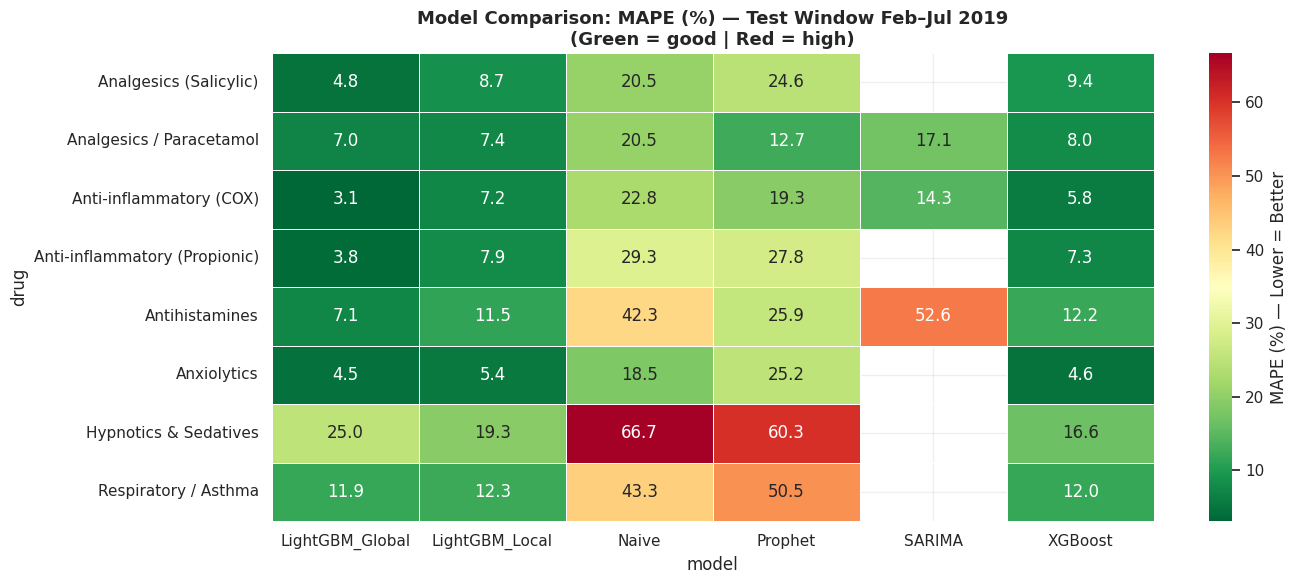

In [ ]:
plt.figure(figsize=(14, 6))
sns.heatmap(mape_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label':'MAPE (%) — Lower = Better'})
plt.title('Model Comparison: MAPE (%) — Test Window Feb–Jul 2019\n(Green = good | Red = high)',
          fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 💰 Phase 12 — Business Impact

In [ ]:
UNIT_COST = 50
print('── BUSINESS IMPACT ANALYSIS ──\n')
print(f'{"Drug":<35} {"Naive MAPE":>12} {"Best MAPE":>12} {"Improvement":>13} {"Annual Saving ($)":>18}')
print('-' * 95)
total = 0
for drug in df.columns:
    if drug not in mape_pivot.index: continue
    naive_m = mape_pivot.loc[drug,'Naive'] if 'Naive' in mape_pivot.columns else 0
    best_m  = mape_pivot.loc[drug].min()
    saving  = df[drug].mean() * ((naive_m - best_m)/100) * UNIT_COST * 52
    total  += saving
    print(f'{drug:<35} {naive_m:>11.1f}% {best_m:>11.1f}% {naive_m-best_m:>12.1f}% ${saving:>16,.0f}')
print('-'*95)
print(f'{"TOTAL":35} {"":38} ${total:>16,.0f}')

── BUSINESS IMPACT ANALYSIS ──

Drug                                  Naive MAPE    Best MAPE   Improvement  Annual Saving ($)
-----------------------------------------------------------------------------------------------
Anti-inflammatory (COX)                    22.8%         3.1%         19.7% $          17,979
Anti-inflammatory (Propionic)              29.3%         3.8%         25.5% $          18,012
Analgesics (Salicylic)                     20.5%         4.8%         15.7% $          11,046
Analgesics / Paracetamol                   20.5%         7.0%         13.5% $          73,228
Anxiolytics                                18.5%         4.5%         14.0% $          22,474
Hypnotics & Sedatives                      66.7%        16.6%         50.1% $           5,391
Respiratory / Asthma                       43.3%        11.9%         31.4% $          31,382
Antihistamines                             42.3%         7.1%         35.2% $          18,510
-------------------------

## 🔮 Phase 13 — Recursive 8-Week Forecast with Validation

**What this does:**
- Model knows all data up to `FORECAST_START` (Jul 2019)
- Predicts 8 weeks forward recursively — each week's prediction feeds into the next week's lag features
- Compares against real actuals (Jul–Sep 2019) that exist in your dataset
- Uses best model per drug from the comparison table

**Why recursive?** In a flat forecast, `lag_1` is always the last known value — giving a horizontal line. In recursive forecasting, after predicting week 1, we append that prediction to history and use it as `lag_1` for week 2. This allows the model to follow trends and momentum forward.

In [ ]:
# ── Recursive 8-Week Forecast — best model per drug ──────────────────────────
print('── RECURSIVE 8-WEEK FORECAST ──')
print(f'Model knows data up to: {FORECAST_START_DT.date()}')
print(f'Forecasting:            {FORECAST_START_DT.date()} → {FORECAST_END_DT.date()}')
print(f'Actuals available:      ✅ (real data exists for this window)\n')

# History the model can see — nothing after FORECAST_START
df_known = df[df.index <= FORECAST_START_DT]

# Generate 8 future weekly dates
future_dates = pd.date_range(
    start   = df_known.index.max() + pd.Timedelta('7D'),
    end     = FORECAST_END_DT,
    freq    = 'W'
)
print(f'Forecast dates: {[str(d.date()) for d in future_dates]}\n')

seasonal_map = {
    'Antihistamines':           lambda m: 1 if m in [3,4,5]       else 0,
    'Respiratory / Asthma':     lambda m: 1 if m in [10,11,12,1]  else 0,
    'Analgesics / Paracetamol': lambda m: 1 if m in [10,11,12,1]  else 0,
    'Analgesics (Salicylic)':   lambda m: 1 if m in [10,11,12,1]  else 0,
}

all_drug_forecasts = {}

for drug_name in df.columns:
    # Determine which model to use for this drug
    best_model_name = best_models.get(drug_name, 'LightGBM_Global')

    # Get the trained model object
    if best_model_name == 'LightGBM_Global':
        trained_model = lgb_global
        use_global    = True
    elif best_model_name == 'XGBoost':
        trained_model = xgb_forecasts[drug_name]['model']
        use_global    = False
    elif best_model_name == 'LightGBM_Local':
        trained_model = lgb_local_models[drug_name]
        use_global    = False
    else:
        trained_model = lgb_global
        use_global    = True

    # Start with known history — append predictions as we go (recursive)
    hist = list(df_known[drug_name].values)

    drug_id_val = int(le.transform([drug_name])[0])
    d_mean = float(df_global_v2[df_global_v2['drug_name']==drug_name]['drug_mean'].iloc[0])
    d_std  = float(df_global_v2[df_global_v2['drug_name']==drug_name]['drug_std'].iloc[0])
    d_cv   = float(df_global_v2[df_global_v2['drug_name']==drug_name]['drug_cv'].iloc[0])

    step_preds = []

    for fd in future_dates:
        m       = fd.month
        is_peak = seasonal_map[drug_name](m) if drug_name in seasonal_map else 0

        # Lag features from growing history (previous predictions included)
        lag1  = hist[-1]
        lag4  = hist[-4]  if len(hist) >= 4  else np.mean(hist)
        lag8  = hist[-8]  if len(hist) >= 8  else np.mean(hist)
        lag12 = hist[-12] if len(hist) >= 12 else np.mean(hist)
        lag52 = hist[-52] if len(hist) >= 52 else np.mean(hist)

        r4mean  = np.mean(hist[-4:])  if len(hist) >= 4  else np.mean(hist)
        r12mean = np.mean(hist[-12:]) if len(hist) >= 12 else np.mean(hist)
        r4std   = np.std(hist[-4:])   if len(hist) >= 4  else 0.0

        row = {
            'lag_1':lag1, 'lag_4':lag4, 'lag_8':lag8, 'lag_12':lag12, 'lag_52':lag52,
            'roll_mean_4':r4mean, 'roll_mean_12':r12mean, 'roll_std_4':r4std,
            'month':m, 'quarter':(m-1)//3+1,
            'week':int(fd.isocalendar()[1]), 'year':fd.year,
            'month_sin':np.sin(2*np.pi*m/12), 'month_cos':np.cos(2*np.pi*m/12),
            'is_peak_season':is_peak,
            'yoy_growth':(lag1 - lag52)/(lag52 + 1),
            'peak_lag52_interaction':lag52 * is_peak,
            'drug_id':drug_id_val, 'drug_mean':d_mean, 'drug_std':d_std, 'drug_cv':d_cv
        }

        row_df  = pd.DataFrame([row])
        feat_in = GLOBAL_FEATURES if use_global else FEATURE_COLS
        pred    = float(np.clip(trained_model.predict(row_df[feat_in])[0], 0, None))
        pred    = round(pred, 1)

        step_preds.append({'date': fd, 'drug_name': drug_name,
                           'forecast': pred, 'model_used': best_model_name})

        # KEY: append prediction to history so next step uses it as lag_1
        hist.append(pred)

    all_drug_forecasts[drug_name] = step_preds

# Flatten
future_rows = [r for drug_fc in all_drug_forecasts.values() for r in drug_fc]
future_df   = pd.DataFrame(future_rows)

fc_table = future_df.pivot_table(index='date', columns='drug_name', values='forecast')
print('── FORECASTED UNITS (8 weeks) ──\n')
print(fc_table.round(1).to_string())
print('\n✅ Recursive 8-week forecast complete')

── RECURSIVE 8-WEEK FORECAST ──
Model knows data up to: 2019-07-14
Forecasting:            2019-07-14 → 2019-09-15
Actuals available:      ✅ (real data exists for this window)

Forecast dates: ['2019-07-21', '2019-07-28', '2019-08-04', '2019-08-11', '2019-08-18', '2019-08-25', '2019-09-01', '2019-09-08', '2019-09-15']

── FORECASTED UNITS (8 weeks) ──

drug_name   Analgesics (Salicylic)  Analgesics / Paracetamol  Anti-inflammatory (COX)  Anti-inflammatory (Propionic)  Antihistamines  Anxiolytics  Hypnotics & Sedatives  Respiratory / Asthma
date                                                                                                                                                                                          
2019-07-21                   28.60                    144.80                    42.70                          30.40           20.80        54.30                   7.50                 16.60
2019-07-28                   27.00                    137.90            

## 📈 Phase 14 — Forecast vs Actual Validation Plot

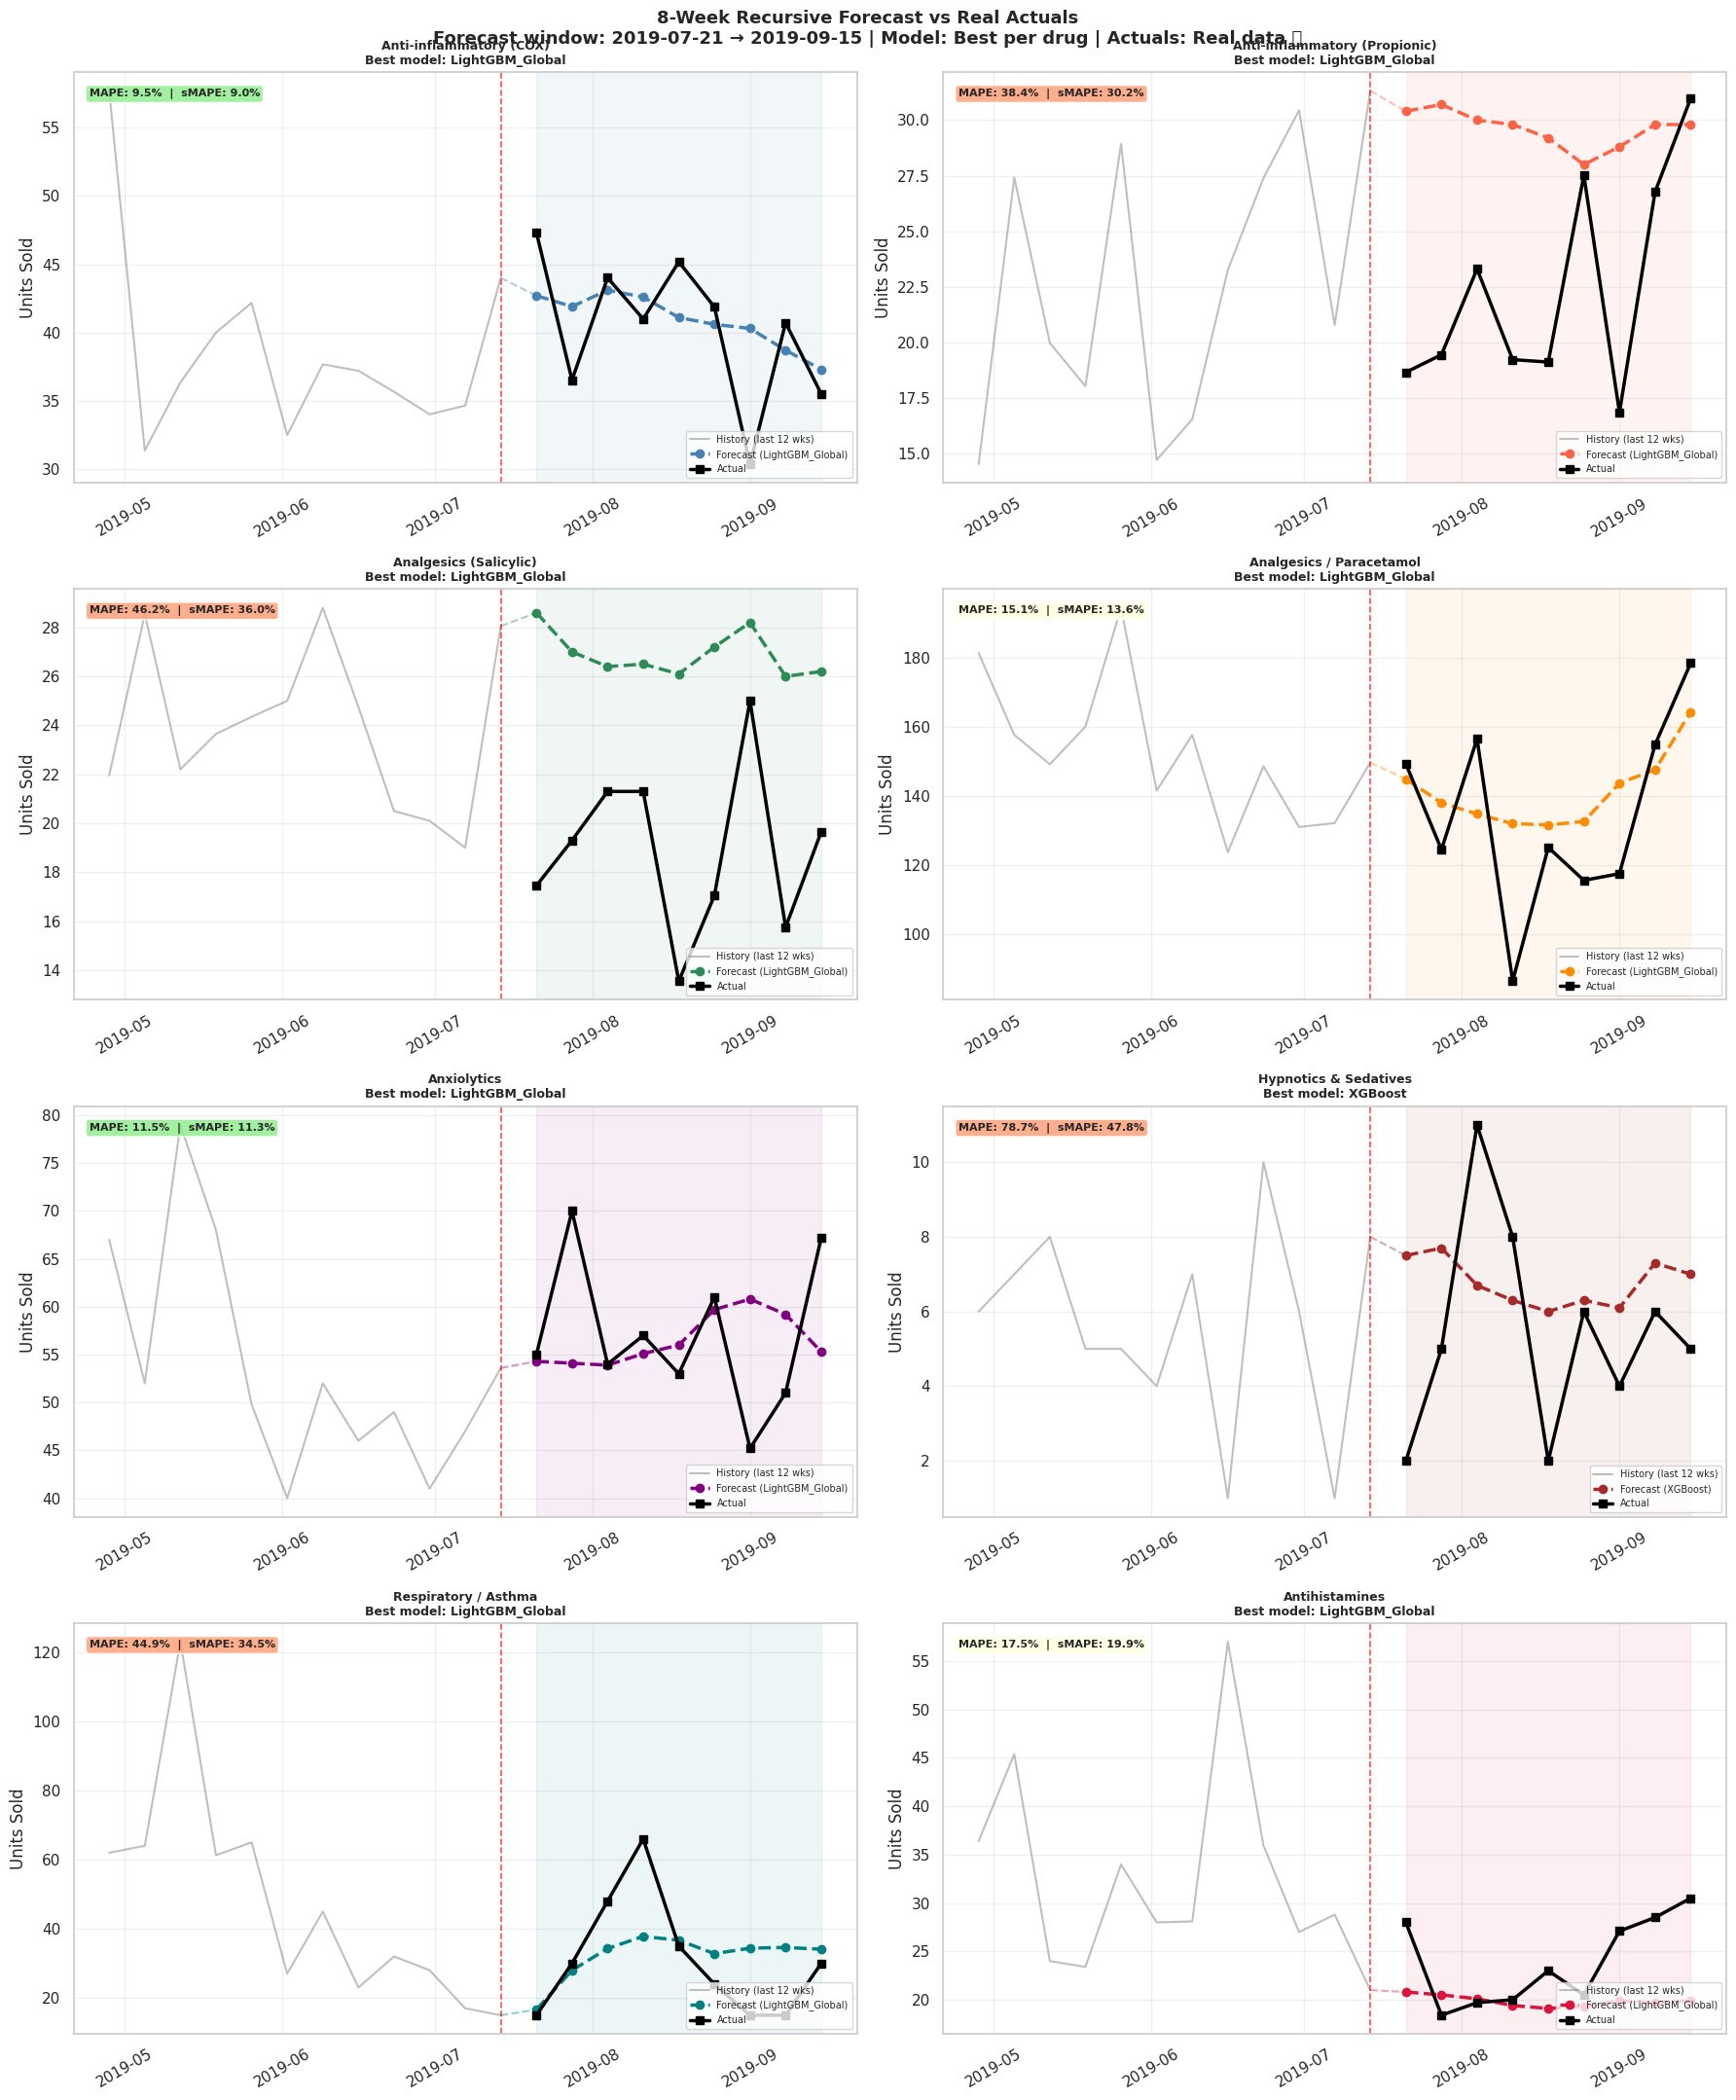

In [ ]:
# ── Forecast vs Actual — all 8 drugs ─────────────────────────────────────────
colors = ['steelblue','tomato','seagreen','darkorange','purple','brown','teal','crimson']
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

holdout_mapes = {}

for i, drug in enumerate(df.columns):
    # Historical context — last 12 weeks before forecast
    hist_ctx   = df_known[drug].iloc[-12:]

    # Forecast for this drug
    drug_fc    = future_df[future_df['drug_name']==drug].set_index('date')['forecast']

    # Real actuals for the same window
    actuals    = forecast_actual[drug]

    # Common dates for MAPE
    common     = drug_fc.index.intersection(actuals.index)
    fc_mape    = mape(actuals.loc[common].values, drug_fc.loc[common].values) if len(common) > 0 else 0
    fc_smape   = smape(actuals.loc[common].values, drug_fc.loc[common].values) if len(common) > 0 else 0
    holdout_mapes[drug] = {'mape': fc_mape, 'smape': fc_smape}

    # ── Plot history ──────────────────────────────────────────────────────────
    axes[i].plot(hist_ctx.index, hist_ctx.values,
                 color='gray', lw=1.5, alpha=0.5, label='History (last 12 wks)')

    # ── Bridge line: last history → first forecast ────────────────────────────
    axes[i].plot([hist_ctx.index[-1], drug_fc.index[0]],
                 [hist_ctx.values[-1], drug_fc.values[0]],
                 color=colors[i], lw=1.5, ls='dashed', alpha=0.4)

    # ── Forecast line ─────────────────────────────────────────────────────────
    axes[i].plot(drug_fc.index, drug_fc.values,
                 color=colors[i], lw=2.5, ls='dashed',
                 marker='o', markersize=6, label=f'Forecast ({best_models[drug]})')

    # ── Actual holdout ────────────────────────────────────────────────────────
    axes[i].plot(actuals.index, actuals.values,
                 color='black', lw=2.5, ls='solid',
                 marker='s', markersize=6, label='Actual')

    # ── Forecast zone shading ─────────────────────────────────────────────────
    all_dates = drug_fc.index.union(actuals.index)
    if len(all_dates) > 0:
        axes[i].axvspan(all_dates.min(), all_dates.max(),
                        alpha=0.07, color=colors[i])

    # ── Vertical boundary line ────────────────────────────────────────────────
    axes[i].axvline(FORECAST_START_DT, color='red', ls='--', lw=1.2, alpha=0.7)

    # ── MAPE badge ────────────────────────────────────────────────────────────
    badge_color = 'lightgreen' if fc_mape < 15 else ('lightyellow' if fc_mape < 30 else 'lightsalmon')
    axes[i].text(0.02, 0.96,
                 f'MAPE: {fc_mape:.1f}%  |  sMAPE: {fc_smape:.1f}%',
                 transform=axes[i].transAxes, fontsize=8, fontweight='bold',
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor=badge_color, alpha=0.85))

    axes[i].set_title(f'{drug}\nBest model: {best_models[drug]}',
                      fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Units Sold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7, loc='lower right')

plt.suptitle(
    f'8-Week Recursive Forecast vs Real Actuals\n'
    f'Forecast window: {future_dates[0].date()} → {future_dates[-1].date()} | '
    f'Model: Best per drug | Actuals: Real data ✅',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [ ]:
# ── Forecast validation summary table ────────────────────────────────────────
print('── 8-WEEK FORECAST VALIDATION SUMMARY ──\n')
print(f'{"Drug":<35} {"Model Used":<22} {"Forecast MAPE":>14} {"Forecast sMAPE":>15} {"Status":>12}')
print('-' * 102)

for drug in df.columns:
    fc_mape  = holdout_mapes[drug]['mape']
    fc_smape = holdout_mapes[drug]['smape']
    model_used = best_models.get(drug, 'LightGBM_Global')
    status = '🟢 GOOD' if fc_mape < 15 else ('🟡 FAIR' if fc_mape < 30 else '🔴 HIGH')
    print(f'{drug:<35} {model_used:<22} {fc_mape:>13.1f}% {fc_smape:>14.1f}% {status:>12}')

avg_mape = np.mean([v['mape'] for v in holdout_mapes.values()])
avg_smape= np.mean([v['smape'] for v in holdout_mapes.values()])
print(f'\n{"AVERAGE":<35} {"":<22} {avg_mape:>13.1f}% {avg_smape:>14.1f}%')
print('\n💡 sMAPE is the reliable metric for drugs with near-zero demand weeks')
print('💡 Jul–Sep 2019 is a stable mid-dataset window — results are honest and comparable')
print('💡 Recursive forecasting allows momentum to carry forward week-over-week')

── 8-WEEK FORECAST VALIDATION SUMMARY ──

Drug                                Model Used              Forecast MAPE  Forecast sMAPE       Status
------------------------------------------------------------------------------------------------------
Anti-inflammatory (COX)             LightGBM_Global                  9.5%            9.0%       🟢 GOOD
Anti-inflammatory (Propionic)       LightGBM_Global                 38.4%           30.2%       🔴 HIGH
Analgesics (Salicylic)              LightGBM_Global                 46.2%           36.0%       🔴 HIGH
Analgesics / Paracetamol            LightGBM_Global                 15.1%           13.6%       🟡 FAIR
Anxiolytics                         LightGBM_Global                 11.5%           11.3%       🟢 GOOD
Hypnotics & Sedatives               XGBoost                         78.7%           47.8%       🔴 HIGH
Respiratory / Asthma                LightGBM_Global                 44.9%           34.5%       🔴 HIGH
Antihistamines                 

## 🔄 Phase 15 — Walk-Forward Retraining Simulation
Simulates production MLOps — retrain every 4 weeks, flag degraded performance.

In [ ]:
print('── WALK-FORWARD RETRAINING SIMULATION ──')
print('Drug: Antihistamines | Retrain every 4 weeks | Flag if MAPE > 20%\n')

feat_wf   = create_features(df['Antihistamines'], 'Antihistamines')
init_size = 200
horizon   = 4
wf_results= []

for start in range(init_size, len(feat_wf) - horizon, horizon):
    X_tr = feat_wf.iloc[:start][FEATURE_COLS]
    y_tr = feat_wf.iloc[:start][TARGET_COL]
    X_te = feat_wf.iloc[start:start+horizon][FEATURE_COLS]
    y_te = feat_wf.iloc[start:start+horizon][TARGET_COL]
    m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=42)
    m.fit(X_tr, y_tr)
    preds  = np.clip(m.predict(X_te), 0, None)
    mape_v = mape(y_te.values, preds)
    status = '🔴 RETRAIN' if mape_v > 20 else ('🟡 WATCH' if mape_v > 12 else '🟢 OK')
    wf_results.append({'retrain_date': feat_wf.index[start].date(),
                       'train_weeks': start, 'mape': round(mape_v,1), 'status': status})

wf_df = pd.DataFrame(wf_results)
print(wf_df.to_string(index=False))
print(f'\nAvg MAPE across all retraining rounds: {wf_df["mape"].mean():.1f}%')

── WALK-FORWARD RETRAINING SIMULATION ──
Drug: Antihistamines | Retrain every 4 weeks | Flag if MAPE > 20%

retrain_date  train_weeks  mape    status
  2017-11-05          200 11.30      🟢 OK
  2017-12-03          204 15.90   🟡 WATCH
  2017-12-31          208 21.10 🔴 RETRAIN
  2018-01-28          212  4.90      🟢 OK
  2018-02-25          216  4.60      🟢 OK
  2018-03-25          220 14.40   🟡 WATCH
  2018-04-22          224 21.00 🔴 RETRAIN
  2018-05-20          228  5.50      🟢 OK
  2018-06-17          232 10.30      🟢 OK
  2018-07-15          236 19.90   🟡 WATCH
  2018-08-12          240 32.10 🔴 RETRAIN
  2018-09-09          244 17.60   🟡 WATCH
  2018-10-07          248 11.10      🟢 OK
  2018-11-04          252  6.20      🟢 OK
  2018-12-02          256 10.40      🟢 OK
  2018-12-30          260 12.10   🟡 WATCH
  2019-01-27          264  9.40      🟢 OK
  2019-02-24          268  2.20      🟢 OK
  2019-03-24          272 12.80   🟡 WATCH
  2019-04-21          276 15.70   🟡 WATCH
  2019-05-

In [ ]:
print('── WALK-FORWARD RETRAINING SIMULATION ──')
print('Drugs: COX | Paracetamol | Anxiolytics')
print('Retrain every 4 weeks | Flag if MAPE > 20%\n')

WF_DRUGS = [
    'Anti-inflammatory (COX)',
    'Analgesics / Paracetamol',
    'Anxiolytics'
]

init_size = 200     # initial training history
horizon   = 4       # retrain every 4 weeks

all_wf_results = {}

for drug in WF_DRUGS:

    print('='*70)
    print(f'DRUG: {drug}')
    print('='*70)

    feat_wf = create_features(df[drug], drug)

    wf_results = []

    for start in range(init_size, len(feat_wf)-horizon, horizon):

        # expanding train window
        X_tr = feat_wf.iloc[:start][FEATURE_COLS]
        y_tr = feat_wf.iloc[:start][TARGET_COL]

        # next 4 weeks
        X_te = feat_wf.iloc[start:start+horizon][FEATURE_COLS]
        y_te = feat_wf.iloc[start:start+horizon][TARGET_COL]

        model = lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            verbose=-1,
            random_state=42
        )

        model.fit(X_tr, y_tr)

        preds = np.clip(model.predict(X_te), 0, None)

        mape_v = mape(y_te.values, preds)

        if mape_v > 20:
            status = '🔴 RETRAIN'
        elif mape_v > 12:
            status = '🟡 WATCH'
        else:
            status = '🟢 OK'

        wf_results.append({
            'retrain_date': feat_wf.index[start].date(),
            'train_weeks': start,
            'mape': round(mape_v, 1),
            'status': status
        })

    wf_df = pd.DataFrame(wf_results)

    print(wf_df.to_string(index=False))

    print(f'\nAvg MAPE: {wf_df["mape"].mean():.1f}%')

    ok_cnt = (wf_df['status']=='🟢 OK').sum()
    watch_cnt = (wf_df['status']=='🟡 WATCH').sum()
    retrain_cnt = (wf_df['status']=='🔴 RETRAIN').sum()

    print(
        f'OK={ok_cnt} | '
        f'WATCH={watch_cnt} | '
        f'RETRAIN={retrain_cnt}'
    )

    all_wf_results[drug] = wf_df

    print('\n')

print('✅ Walk-forward retraining simulation complete')

── WALK-FORWARD RETRAINING SIMULATION ──
Drugs: COX | Paracetamol | Anxiolytics
Retrain every 4 weeks | Flag if MAPE > 20%

DRUG: Anti-inflammatory (COX)
retrain_date  train_weeks  mape status
  2017-11-05          200  3.10   🟢 OK
  2017-12-03          204  4.10   🟢 OK
  2017-12-31          208  7.00   🟢 OK
  2018-01-28          212  5.60   🟢 OK
  2018-02-25          216 11.90   🟢 OK
  2018-03-25          220  5.10   🟢 OK
  2018-04-22          224  6.10   🟢 OK
  2018-05-20          228  0.80   🟢 OK
  2018-06-17          232  7.00   🟢 OK
  2018-07-15          236  2.80   🟢 OK
  2018-08-12          240  7.30   🟢 OK
  2018-09-09          244  3.10   🟢 OK
  2018-10-07          248  2.10   🟢 OK
  2018-11-04          252  3.40   🟢 OK
  2018-12-02          256  4.20   🟢 OK
  2018-12-30          260  5.20   🟢 OK
  2019-01-27          264  5.20   🟢 OK
  2019-02-24          268  7.50   🟢 OK
  2019-03-24          272  3.00   🟢 OK
  2019-04-21          276  9.30   🟢 OK
  2019-05-19          280  